# MLP für 5×7-Ziffernerkennung

**Goodie-Modul, Algorithmen & Datenstrukturen — von Hand, mit Backpropagation**

Wir bauen ein einfaches Multi-Layer-Perzeptron (MLP) mit *einer* versteckten Schicht
und trainieren es darauf, Ziffern in einer 5×7-ASCII-Matrix zu erkennen. Die
gesamte Backpropagation wird mit `numpy` ausgeschrieben — kein PyTorch, kein
TensorFlow, keine Magie.

Lernziele:
1. Übergang vom Perzeptron zum MLP
2. Forward Pass und Backpropagation als saubere mathematische Rezepte
3. Parameter zählen — und sehen, warum CNNs für reale Bildgrößen
   unverzichtbar sind

Wir benutzen Sigmoid + quadratische Loss; das ist die direkteste
Verallgemeinerung der Perzeptron-Regel und erlaubt die einfachste
Backprop-Herleitung.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)

## 1. Die Trainingsdaten: 5×7-Ziffern als ASCII-Art

Jede Ziffer ist ein 5×7-Raster (5 Spalten, 7 Zeilen → 35 Pixel). `#` markiert
einen gesetzten Pixel, `.` einen leeren.

In [6]:
DIGITS_RAW = {
    0: """
.###.
#...#
#...#
#...#
#...#
#...#
.###.""",
    1: """
..#..
.##..
..#..
..#..
..#..
..#..
.###.""",
    2: """
.###.
#...#
....#
...#.
..#..
.#...
#####""",
    3: """
.###.
#...#
....#
..##.
....#
#...#
.###.""",
    4: """
#...#
#...#
#...#
#####
....#
....#
....#""",
    5: """
#####
#....
####.
....#
....#
#...#
.###.""",
    6: """
.###.
#...#
#....
####.
#...#
#...#
.###.""",
    7: """
#####
....#
....#
...#.
..#..
.#...
#....""",
    8: """
.###.
#...#
#...#
.###.
#...#
#...#
.###.""",
    9: """
.###.
#...#
#...#
.####
....#
#...#
.###.""",
}

def parse_digit(s):
    """Wandelt ASCII-Art in einen 35-dim Vektor (0/1) um."""
    rows = [r for r in s.strip().split("\n")]
    assert len(rows) == 7 and all(len(r) == 5 for r in rows)
    return np.array([[1.0 if c == "#" else 0.0 for c in r] for r in rows]).flatten()

X_clean = np.array([parse_digit(DIGITS_RAW[d]) for d in range(10)])
Y_clean = np.eye(10)   # One-Hot Labels

print(f"Eingabematrix X_clean: {X_clean.shape}  (10 Ziffern x 35 Pixel)")
print(f"Label-Matrix  Y_clean: {Y_clean.shape}  (One-Hot)")

Eingabematrix X_clean: (10, 35)  (10 Ziffern x 35 Pixel)
Label-Matrix  Y_clean: (10, 10)  (One-Hot)


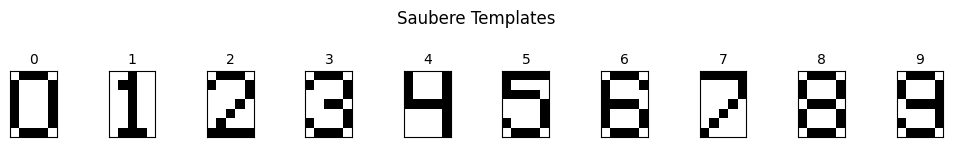

In [7]:
def show_digits(X, labels=None, title="", ncols=10):
    """Visualisiert eine Liste von 35-dim Ziffern-Vektoren."""
    n = len(X)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.0, nrows*1.4))
    if nrows == 1: axes = axes.reshape(1, -1)
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(X[i].reshape(7, 5), cmap="gray_r", vmin=0, vmax=1)
            if labels is not None:
                ax.set_title(str(labels[i]), fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

show_digits(X_clean, labels=list(range(10)), title="Saubere Templates")

## 2. Augmentierung: verrauschte Trainingsbeispiele

Mit nur 10 Trainingsbeispielen würde das Netz sich die Templates schlicht
auswendig lernen. Wir erzeugen für jede Ziffer mehrere verrauschte Varianten,
indem wir zufällig je 2 Pixel umkippen — leichte Schreibfehler simulieren,
quasi.

Trainingsdaten: (410, 35), Labels: (410, 10)


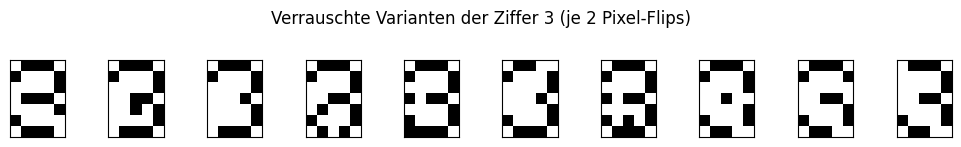

In [8]:
def augment(x, n_flips, rng):
    """Kippe n_flips zufaellige Pixel."""
    x = x.copy()
    idx = rng.choice(len(x), size=n_flips, replace=False)
    x[idx] = 1.0 - x[idx]
    return x

rng = np.random.default_rng(42)
N_PER_DIGIT = 40

X_train = []; Y_train = []
for d in range(10):
    X_train.append(X_clean[d]); Y_train.append(Y_clean[d])    # Original immer dabei
    for _ in range(N_PER_DIGIT):
        X_train.append(augment(X_clean[d], n_flips=2, rng=rng))
        Y_train.append(Y_clean[d])
X_train = np.array(X_train)
Y_train = np.array(Y_train)
print(f"Trainingsdaten: {X_train.shape}, Labels: {Y_train.shape}")

# Beispiel-Augmentierungen fuer die Ziffer 3
examples_3 = [augment(X_clean[3], n_flips=2, rng=rng) for _ in range(10)]
show_digits(examples_3, title="Verrauschte Varianten der Ziffer 3 (je 2 Pixel-Flips)")

## 3. Das MLP — Architektur

Wir bauen ein Netz mit drei Schichten:

- **Input:** 35 Neuronen (ein Pixel pro Eingang)
- **Hidden:** 16 Neuronen, sigmoid-aktiviert
- **Output:** 10 Neuronen (eines pro Ziffer), sigmoid-aktiviert

Forward Pass für Schicht $\ell$:
$$ z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)}, \qquad a^{(\ell)} = \sigma(z^{(\ell)}) $$

mit der Sigmoid-Funktion $\sigma(z) = \frac{1}{1 + e^{-z}}$.

Loss (quadratisch):
$$ L = \tfrac{1}{2} \sum_k (a^{(L)}_k - y_k)^2 $$

Die Backpropagation-Gleichungen (Nielsen-Notation):
$$ \delta^{(L)} = (a^{(L)} - y) \odot \sigma'(z^{(L)}) $$
$$ \delta^{(\ell)} = (W^{(\ell+1)})^\top \delta^{(\ell+1)} \odot \sigma'(z^{(\ell)}) $$
$$ \frac{\partial L}{\partial W^{(\ell)}} = \delta^{(\ell)} (a^{(\ell-1)})^\top, \qquad \frac{\partial L}{\partial b^{(\ell)}} = \delta^{(\ell)} $$

Im Code sind das vier Zeilen pro Layer.

In [5]:
class MLP:
    """Minimales Multi-Layer-Perzeptron mit Backpropagation."""

    def __init__(self, sizes, seed=42):
        # sizes z.B. [35, 16, 10]
        self.sizes = sizes
        rng = np.random.default_rng(seed)
        # Xavier-aehnliche Initialisierung: Skalierung mit 1/sqrt(fan_in)
        self.W = [rng.normal(0, 1.0/np.sqrt(a), (b, a))
                  for a, b in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros((b, 1)) for b in sizes[1:]]

    @staticmethod
    def sigma(z):
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def sigma_prime(z):
        s = MLP.sigma(z)
        return s * (1 - s)

    def forward(self, x):
        """Vorwaertsdurchlauf: liefert Aktivierung der Output-Schicht."""
        a = x.reshape(-1, 1)
        for W, b in zip(self.W, self.b):
            a = self.sigma(W @ a + b)
        return a

    def backprop(self, x, y):
        """Berechnet Gradienten fuer ein einzelnes (x, y)-Paar."""
        x = x.reshape(-1, 1); y = y.reshape(-1, 1)

        # --- Forward Pass mit gespeicherten Zwischenwerten ---
        a = x
        activations = [a]    # a^{(0)}, a^{(1)}, ..., a^{(L)}
        zs = []              # z^{(1)}, ..., z^{(L)}
        for W, b in zip(self.W, self.b):
            z = W @ a + b
            zs.append(z)
            a = self.sigma(z)
            activations.append(a)

        # --- Backward Pass ---
        # Output-Delta: (a^L - y) (.) sigma'(z^L)
        delta = (activations[-1] - y) * self.sigma_prime(zs[-1])

        gW = [None] * len(self.W)
        gb = [None] * len(self.b)
        gW[-1] = delta @ activations[-2].T
        gb[-1] = delta

        # Rueckwaerts durch verbleibende Schichten
        for l in range(2, len(self.W) + 1):
            delta = (self.W[-l+1].T @ delta) * self.sigma_prime(zs[-l])
            gW[-l] = delta @ activations[-l-1].T
            gb[-l] = delta

        return gW, gb

    def train(self, X, Y, epochs, lr, verbose=True):
        """Stochastic Gradient Descent, ein Beispiel pro Update."""
        n = len(X)
        history = []
        rng = np.random.default_rng(0)
        for epoch in range(epochs):
            perm = rng.permutation(n)
            total_loss = 0.0
            for i in perm:
                gW, gb = self.backprop(X[i], Y[i])
                self.W = [W - lr * gw for W, gw in zip(self.W, gW)]
                self.b = [b - lr * gbi for b, gbi in zip(self.b, gb)]
                a = self.forward(X[i])
                total_loss += 0.5 * np.sum((a - Y[i].reshape(-1, 1))**2)
            avg = total_loss / n
            history.append(avg)
            if verbose and (epoch % 25 == 0 or epoch == epochs - 1):
                acc = self.accuracy(X, Y)
                print(f"  Epoch {epoch:4d}  loss={avg:.4f}  acc={acc:.3f}")
        return history

    def predict(self, x):
        return int(np.argmax(self.forward(x)))

    def accuracy(self, X, Y):
        preds = np.array([self.predict(x) for x in X])
        truth = np.argmax(Y, axis=1)
        return float(np.mean(preds == truth))

## 4. Training

In [6]:
net = MLP(sizes=[35, 16, 10], seed=42)

# Parameter zaehlen
n_W = sum(W.size for W in net.W)
n_b = sum(b.size for b in net.b)
print(f"Parameter im Netz: {n_W} Gewichte + {n_b} Biases = {n_W + n_b} insgesamt\n")

history = net.train(X_train, Y_train, epochs=200, lr=0.5)

Parameter im Netz: 720 Gewichte + 26 Biases = 746 insgesamt

  Epoch    0  loss=0.3520  acc=0.629
  Epoch   25  loss=0.0023  acc=1.000
  Epoch   50  loss=0.0011  acc=1.000
  Epoch   75  loss=0.0007  acc=1.000
  Epoch  100  loss=0.0005  acc=1.000
  Epoch  125  loss=0.0004  acc=1.000
  Epoch  150  loss=0.0003  acc=1.000
  Epoch  175  loss=0.0003  acc=1.000
  Epoch  199  loss=0.0002  acc=1.000


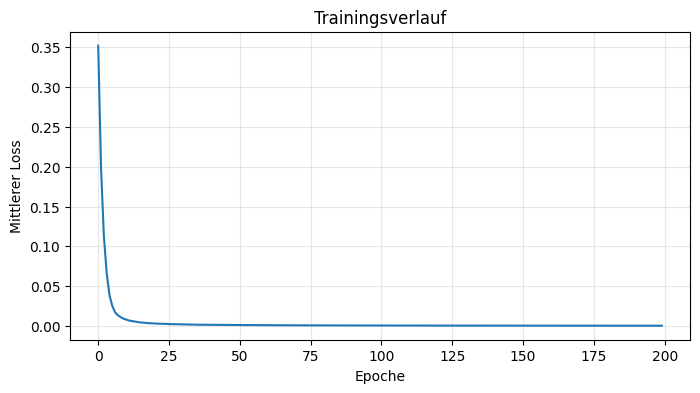

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.xlabel("Epoche"); plt.ylabel("Mittlerer Loss")
plt.title("Trainingsverlauf")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Evaluation auf ungesehenen verrauschten Daten

In [8]:
rng_test = np.random.default_rng(999)

def make_test(n_flips, n_per_digit=20):
    X = []; Y = []
    for d in range(10):
        for _ in range(n_per_digit):
            X.append(augment(X_clean[d], n_flips=n_flips, rng=rng_test))
            Y.append(Y_clean[d])
    return np.array(X), np.array(Y)

print("Train-Accuracy:                ", net.accuracy(X_train, Y_train))
print("Originale Templates:           ", net.accuracy(X_clean, Y_clean))
for k in [1, 2, 3, 4, 5, 6]:
    Xt, Yt = make_test(n_flips=k)
    print(f"Test-Accuracy ({k} Pixel-Flips):  {net.accuracy(Xt, Yt):.3f}")

Train-Accuracy:                 1.0
Originale Templates:            1.0
Test-Accuracy (1 Pixel-Flips):  0.975
Test-Accuracy (2 Pixel-Flips):  0.985
Test-Accuracy (3 Pixel-Flips):  0.945
Test-Accuracy (4 Pixel-Flips):  0.920
Test-Accuracy (5 Pixel-Flips):  0.900
Test-Accuracy (6 Pixel-Flips):  0.875


Beim Anwachsen des Rauschens bricht die Genauigkeit kontinuierlich ein.
Das ist das erwartete Verhalten: das Netz hat keine Kenntnis von
*Translationsinvarianz* oder lokaler Struktur — jedes Pixel ist ein
unabhängiges Feature.

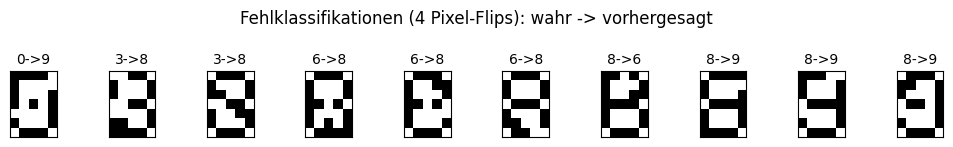

In [9]:
# Welche Beispiele werden falsch klassifiziert?
X_test, Y_test = make_test(n_flips=4, n_per_digit=20)
preds = np.array([net.predict(x) for x in X_test])
truth = np.argmax(Y_test, axis=1)
wrong = np.where(preds != truth)[0]

if len(wrong) > 0:
    sel = wrong[:10]
    show_digits(
        X_test[sel],
        labels=[f"{truth[i]}->{preds[i]}" for i in sel],
        title="Fehlklassifikationen (4 Pixel-Flips): wahr -> vorhergesagt"
    )
else:
    print("Keine Fehler in dieser Stichprobe.")

## 6. Was hat die versteckte Schicht gelernt?

Jedes Hidden-Neuron lernt ein Gewichtsmuster über die 35 Eingangspixel.
Wenn wir diese Gewichte als 7×5-Bild anzeigen, erkennen wir Strukturen
wie Kanten, Schleifen oder Endpunkte — das ist die "Feature-Detektor"-Lesart.

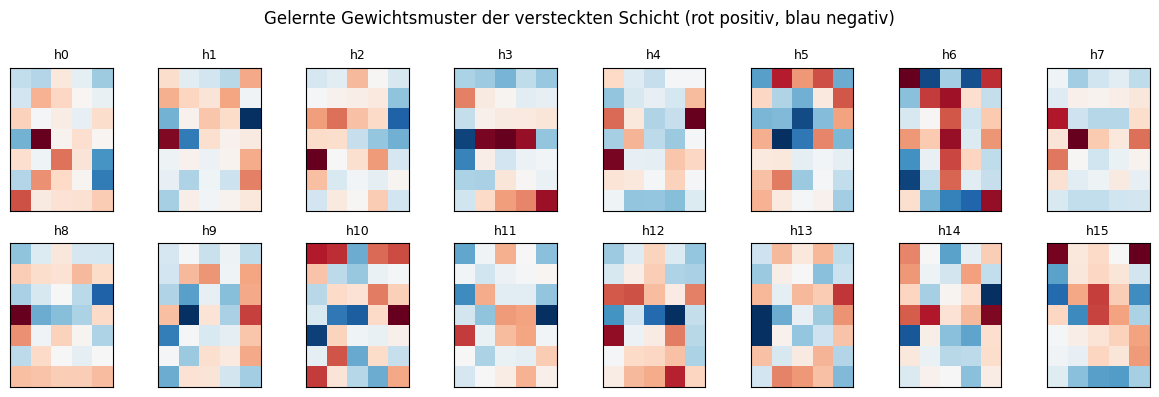

In [10]:
W1 = net.W[0]   # Shape: (16, 35)
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    w = W1[i].reshape(7, 5)
    vmax = np.abs(w).max()
    ax.imshow(w, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"h{i}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Gelernte Gewichtsmuster der versteckten Schicht (rot positiv, blau negativ)")
plt.tight_layout(); plt.show()

## 7. Komplexitäts-Diskussion: warum CNNs?

Unser Netz hat:

| Schicht | Eingang | Ausgang | Gewichte | Biases |
|---------|---------|---------|----------|--------|
| Hidden  | 35      | 16      | 560      | 16     |
| Output  | 16      | 10      | 160      | 10     |
| **Σ**   |         |         | **720**  | **26** |

Das sind 746 Parameter — handhabbar. Was passiert, wenn wir die Auflösung
hochdrehen?

In [11]:
def mlp_params(input_size, hidden_size, output_size):
    return input_size*hidden_size + hidden_size + hidden_size*output_size + output_size

scenarios = [
    ('5x7 ASCII (unsere Ziffern)',         5*7,        16,   10),
    ('28x28 MNIST',                        28*28,      128,  10),
    ('64x64 Logo-Erkennung (Graustufen)',  64*64,      256,  20),
    ('224x224 ImageNet-Bild',              224*224,    512, 1000),
    ('512x512 medizinisches Bild',         512*512,    512,   10),
]

print(f"{'Szenario':<45s} {'Input':>8s} {'Parameter':>12s}")
print("-" * 70)
for name, inp, h, out in scenarios:
    p = mlp_params(inp, h, out)
    print(f"{name:<45s} {inp:>8d} {p:>12,}")

Szenario                                         Input    Parameter
----------------------------------------------------------------------
5x7 ASCII (unsere Ziffern)                          35          746
28x28 MNIST                                        784      101,770
64x64 Logo-Erkennung (Graustufen)                 4096    1,053,972
224x224 ImageNet-Bild                            50176   26,203,624
512x512 medizinisches Bild                      262144  134,223,370


**Das ist das Skalierungsproblem.** Bei einem 224×224-Bild allein in der
ersten Vollverbundenen-Schicht: ca. 25 Millionen Gewichte. Das passt nicht
mehr in einen sinnvollen Trainingsdatensatz hinein, geschweige denn auf
brauchbare Hardware der 1990er.

### Wo ist die Symmetrie?

Das vollverbundene MLP behandelt jeden Pixel als unabhängiges Feature. Es
weiß nicht:

- Eine **Kante oben links** ist *dasselbe* Feature wie eine *Kante unten
  rechts* — nur an anderer Stelle. Das MLP lernt diese Translationen
  als völlig getrennte Muster und braucht entsprechend viele Beispiele.
- **Lokale Pixel** sind stärker korreliert als entfernte. Das MLP nutzt
  diese Lokalität nicht.

### Convolutional Neural Networks: Symmetrie ausnutzen

Das CNN-Rezept besteht im Wesentlichen aus zwei Tricks:

1. **Weight Sharing.** Statt für jede Position eigene Gewichte zu lernen,
   wird *ein* kleiner Filter (z. B. 3×3) über das gesamte Bild geschoben.
   Aus 224·224·c Gewichten pro Hidden-Unit werden 3·3·c Gewichte — und
   das *für die ganze Schicht zusammen*.
2. **Lokale Receptive Fields.** Jedes Hidden-Neuron sieht nur einen kleinen
   Ausschnitt des Bildes statt aller Pixel.

Das ist mathematisch eine **Faltung**, gruppentheoretisch die Ausnutzung
der **Translationsäquivarianz**. Im Komplexitätsbild: wir reduzieren die
Parameteranzahl um Größenordnungen, weil wir Vorwissen über die
Datensymmetrie ins Modell einbauen.

**Verbindung zum übergeordneten Modul-Topos:** Genau wie DBSCAN durch eine
geeignete *Datenstruktur* (k-d Tree) handhabbar wurde, wird die
Bilderkennung erst durch eine geeignete *Modellstruktur* (Faltung statt
Vollverbindung) handhabbar. In beiden Fällen reduziert *Wissen über die
Struktur des Problems* die effektive Komplexität.

## 8. Zusammenfassung

- Ein winziges MLP mit 746 Parametern lernt 5×7-Ziffern in unter einer
  Minute auf der CPU.
- Backpropagation ist mathematisch eine direkte Anwendung der Kettenregel
  und passt in 20 Zeilen `numpy`.
- Die Vollverbundenheit ist der Engpass: ohne Symmetrieausnutzung skaliert
  das Modell quadratisch in der Bildgröße.
- CNNs sind keine "magische Verbesserung", sondern eine
  *strukturelle Reduktion* — sie codieren das Vorwissen, dass dasselbe
  Feature an verschiedenen Bildpositionen dieselbe Bedeutung hat.
